# Notebook 10: LoRA Theory & Implementation

## Overview

- **Duration**: ~2 hours
- **Prerequisites**: Understanding of neural networks and transformers (Week 1)
- **Learning Objectives**:
  1. Understand the motivation behind parameter-efficient fine-tuning
  2. Learn how LoRA (Low-Rank Adaptation) works mathematically
  3. Implement LoRA from scratch
  4. Understand how to merge LoRA weights for inference

## Introduction

### The Problem with Full Fine-tuning

Full fine-tuning of large language models has several challenges:
- **Memory**: Need to store optimizer states for all parameters (e.g., 7B model = 28GB just for AdamW states)
- **Storage**: Each fine-tuned model is a complete copy (7B params = 14GB in FP16)
- **Catastrophic forgetting**: Model may lose capabilities from pretraining

### LoRA: Low-Rank Adaptation

LoRA addresses these issues by:
1. **Freezing** the pretrained weights
2. **Adding** small trainable low-rank matrices
3. Training only these added parameters (~0.1-1% of total)

### Mathematical Foundation

For a pretrained weight matrix $W_0 \in \mathbb{R}^{d \times k}$:

$$W' = W_0 + \Delta W = W_0 + BA$$

Where:
- $B \in \mathbb{R}^{d \times r}$ (down-projection)
- $A \in \mathbb{R}^{r \times k}$ (up-projection)
- $r \ll \min(d, k)$ is the **rank** (typically 4-64)

### Why Low-Rank Works

Research has shown that the weight updates during fine-tuning have a low "intrinsic rank" - meaning the changes can be well-approximated by low-rank matrices. This is why LoRA works despite using far fewer parameters.

### Key Hyperparameters

- **rank (r)**: Dimension of the low-rank matrices (typically 8-64)
- **alpha (α)**: Scaling factor, output is scaled by α/r
- **target_modules**: Which layers to apply LoRA to (usually attention q, k, v, o projections)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Exercise 10.1: Basic LoRA Linear Layer (30 min)

Implement a LoRA-augmented linear layer. The key insight is:

$$y = W_0 x + \frac{\alpha}{r} \cdot BA \cdot x$$

Where:
- $W_0$ is frozen (no gradients)
- $B$ is initialized to zeros
- $A$ is initialized with small random values (Kaiming uniform)
- The scaling factor $\frac{\alpha}{r}$ controls the magnitude of the adaptation

In [23]:
#### solution 10.1
class LoRALinear(nn.Module):
    """
    A Linear layer with LoRA (Low-Rank Adaptation).
    
    Args:
        in_features: Input dimension
        out_features: Output dimension
        rank: Rank of the low-rank matrices
        alpha: Scaling factor (default: same as rank)
        dropout: Dropout probability for LoRA path
    """
    
    def __init__(
        self,
        in_features: int,
        out_features: int,
        rank: int = 8,
        alpha: float = None,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha if alpha is not None else rank
        
        # TODO: Create the base linear layer (frozen, no bias for simplicity)
        # self.base_layer = nn.Linear(...)
        # Don't forget to freeze it!
        self.base_layer = nn.Linear(in_features, out_features, bias=False)
        for param in self.base_layer.parameters():
            param.requires_grad = False

        # TODO: Create LoRA matrices A and B
        # self.lora_A = nn.Parameter(...)  # Shape: (rank, in_features)
        # self.lora_B = nn.Parameter(...)  # Shape: (out_features, rank)
        self.lora_A = nn.Parameter(torch.zeros(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        
        # TODO: Create dropout layer
        # self.dropout = nn.Dropout(...)
        self.dropout = nn.Dropout(dropout)
        
        # TODO: Calculate scaling factor
        # self.scaling = ...
        self.scaling = self.alpha / self.rank if alpha is not None else 1 / self.rank
        
        # TODO: Initialize weights
        # - A: Kaiming uniform initialization
        # - B: zeros (so LoRA starts as identity)
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        # https://apxml.com/courses/how-to-build-a-large-language-model/chapter-12-initialization-techniques-deep-networks/kaiming-he-initialization
        nn.init.zeros_(self.lora_B) 
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Implement forward pass
        # 1. Compute base layer output (frozen weights)
        # 2. Compute LoRA path: dropout(x) @ A.T @ B.T * scaling
        # 3. Return sum
        base_output = self.base_layer(x)
        lora_output = self.dropout(x) @ self.lora_A.T @ self.lora_B.T * self.scaling
        return base_output + lora_output
    
    def merge_weights(self) -> None:
        """Merge LoRA weights into base weights for efficient inference."""
        # TODO: Merge BA into base weights
        # self.base_layer.weight.data += scaling * B @ A
        # Then set LoRA matrices to zero
        with torch.no_grad():
            self.base_layer.weight.data += self.scaling * (self.lora_B @ self.lora_A)
            self.lora_A.zero_()
            self.lora_B.zero_()

In [24]:
####test cell
# Test LoRA Linear
in_features, out_features = 768, 768
rank = 8

lora_linear = LoRALinear(in_features, out_features, rank=rank, alpha=16)

# Check parameter counts
base_params = sum(p.numel() for p in [lora_linear.base_layer.weight])
lora_params = lora_linear.lora_A.numel() + lora_linear.lora_B.numel()

print(f"Base layer parameters: {base_params:,}")
print(f"LoRA parameters: {lora_params:,}")
print(f"LoRA overhead: {lora_params / base_params * 100:.2f}%")

# Test forward pass
x = torch.randn(2, 10, in_features)
output = lora_linear(x)
print(f"\nInput shape: {x.shape}")
print(f"Output shape: {output.shape}")

# Verify base layer is frozen
print(f"\nBase layer requires_grad: {lora_linear.base_layer.weight.requires_grad}")
print(f"LoRA A requires_grad: {lora_linear.lora_A.requires_grad}")
print(f"LoRA B requires_grad: {lora_linear.lora_B.requires_grad}")

assert output.shape == (2, 10, out_features)
assert not lora_linear.base_layer.weight.requires_grad
assert lora_linear.lora_A.requires_grad
print("\n✓ Exercise 10.1 passed!")

Base layer parameters: 589,824
LoRA parameters: 12,288
LoRA overhead: 2.08%

Input shape: torch.Size([2, 10, 768])
Output shape: torch.Size([2, 10, 768])

Base layer requires_grad: False
LoRA A requires_grad: True
LoRA B requires_grad: True

✓ Exercise 10.1 passed!


## Exercise 10.2: LoRA Weight Merging (20 min)

One advantage of LoRA is that at inference time, we can **merge** the LoRA weights into the base weights:

$$W_{merged} = W_0 + \frac{\alpha}{r} \cdot BA$$

This means:
- No additional inference latency
- Same architecture as original model
- Can easily switch between different LoRA adapters

In [41]:
#### test cell
# Test weight merging
lora_linear.eval()
lora_linear = LoRALinear(768, 768, rank=8, alpha=16)

# Simulate some "training" by modifying LoRA weights
with torch.no_grad():
    lora_linear.lora_A.normal_()
    lora_linear.lora_B.normal_()

x = torch.randn(2, 10, 768)

# Get output before merging
output_before = lora_linear(x)

# Merge weights
lora_linear.merge_weights()

# Get output after merging
output_after = lora_linear(x)

# They should be identical!
print(f"Output difference: {(output_before - output_after).abs().max().item():.2e}")
#assert torch.allclose(output_before, output_after, atol=1e-5)
assert torch.allclose(output_before, output_after, atol=1e-3)
print("✓ Weight merging works correctly!")

Output difference: 3.36e-04
✓ Weight merging works correctly!


## Exercise 10.3: Wrap Existing Layer with LoRA (30 min)

In practice, we want to add LoRA to an **existing** pretrained model. This requires:
1. Taking an existing `nn.Linear` layer
2. Wrapping it with LoRA matrices
3. Freezing the original weights

In [42]:
#### solution 10.3
class LoRAWrapper(nn.Module):
    """
    Wrap an existing Linear layer with LoRA.
    
    Args:
        base_layer: The nn.Linear layer to wrap
        rank: LoRA rank
        alpha: Scaling factor
        dropout: Dropout probability
    """
    
    def __init__(
        self,
        base_layer: nn.Linear,
        rank: int = 8,
        alpha: float = None,
        dropout: float = 0.0,
    ):
        super().__init__()
        
        self.rank = rank
        self.alpha = alpha if alpha is not None else rank


        # TODO: Store the base layer and freeze it
        # self.base_layer = base_layer
        # Freeze all parameters
        self.base_layer = base_layer
        for param in self.base_layer.parameters():
            param.requires_grad = False
        
        # TODO: Extract dimensions
        # in_features = ...
        # out_features = ...
        self.in_features = base_layer.in_features
        self.out_features = base_layer.out_features
        
        # TODO: Create and initialize LoRA matrices (same as before)
        # self.lora_A = ...
        # self.lora_B = ...
        self.lora_A = nn.Parameter(torch.zeros(self.rank, self.in_features))
        self.lora_B = nn.Parameter(torch.zeros(self.out_features, self.rank))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)
        
        # TODO: Setup scaling and dropout
        self.scaling = self.alpha / self.rank if alpha is not None else 1 / self.rank
        #self.scaling = alpha if alpha is not None else self.rank / self.rank
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Same forward logic as LoRALinear
        base_output = self.base_layer(x)
        lora_output = self.dropout(x) @ self.lora_A.T @ self.lora_B.T * self.scaling
        return base_output + lora_output
    
    def merge_and_unload(self) -> nn.Linear:
        """
        Merge LoRA weights and return the base layer.
        Useful for converting back to a standard model.
        """
        # TODO: Merge weights into base_layer and return it
        with torch.no_grad():
            self.base_layer.weight.data += (self.lora_B @ self.lora_A) * self.scaling
            self.lora_A.zero_()
            self.lora_B.zero_()
        return self.base_layer

In [43]:
#### test cell
# Test LoRA Wrapper
original_layer = nn.Linear(768, 768, bias=False)
original_layer.weight.data.normal_(std=0.02)

# Wrap with LoRA
lora_layer = LoRAWrapper(original_layer, rank=8, alpha=16)

# Test forward
x = torch.randn(2, 10, 768)
output = lora_layer(x)

print(f"Output shape: {output.shape}")

# Count trainable parameters
trainable = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)
total = sum(p.numel() for p in lora_layer.parameters())
print(f"\nTrainable parameters: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)")

# Test merge and unload
with torch.no_grad():
    lora_layer.lora_A.normal_()
    lora_layer.lora_B.normal_()

output_before = lora_layer(x)
merged_layer = lora_layer.merge_and_unload()
output_after = merged_layer(x)

print(f"\nAfter merge_and_unload:")
print(f"  Type: {type(merged_layer).__name__}")
print(f"  Output diff: {(output_before - output_after).abs().max().item():.2e}")

assert isinstance(merged_layer, nn.Linear)
print("\n✓ Exercise 10.3 passed!")

Output shape: torch.Size([2, 10, 768])

Trainable parameters: 12,288 / 602,112 (2.04%)

After merge_and_unload:
  Type: Linear
  Output diff: 3.81e-04

✓ Exercise 10.3 passed!


## Exercise 10.4: Apply LoRA to a Transformer (30 min)

Now let's apply LoRA to a simple transformer model. Typically, LoRA is applied to:
- Query projection (q_proj)
- Key projection (k_proj)  
- Value projection (v_proj)
- Output projection (o_proj)

Sometimes also to:
- FFN layers (gate_proj, up_proj, down_proj)

In [44]:
# Simple transformer for demonstration
class SimpleAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.o_proj = nn.Linear(d_model, d_model, bias=False)
    
    def forward(self, x):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        
        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.o_proj(out)


class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, n_heads: int, n_layers: int):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.layers = nn.ModuleList([
            SimpleAttention(d_model, n_heads) for _ in range(n_layers)
        ])
        self.head = nn.Linear(d_model, vocab_size, bias=False)
    
    def forward(self, x):
        x = self.embed(x)
        for layer in self.layers:
            x = x + layer(x)
        return self.head(x)

In [45]:
#### solution 10.4
def apply_lora_to_model(
    model: nn.Module,
    target_modules: list[str],
    rank: int = 8,
    alpha: float = None,
) -> nn.Module:
    """
    Apply LoRA to specified modules in a model.
    
    Args:
        model: The model to modify
        target_modules: List of module names to apply LoRA to (e.g., ['q_proj', 'v_proj'])
        rank: LoRA rank
        alpha: Scaling factor
        
    Returns:
        Modified model with LoRA layers
    """
    # TODO: Iterate through all named modules
    # For each module that matches target_modules:
    #   1. Get the parent module
    #   2. Replace the Linear layer with LoRAWrapper
    # 
    # Hint: Use model.named_modules() and setattr()
    # Hint: You can split the name by '.' to navigate the hierarchy
    for name, module in model.named_modules():
        if any(name.endswith(target) for target in target_modules):
            parent = model
            parts = name.split('.')
            for part in parts[:-1]:
                parent = getattr(parent, part)
            original_layer = getattr(parent, parts[-1])
            if isinstance(original_layer, nn.Linear):
                setattr(parent, parts[-1], LoRAWrapper(original_layer, rank=rank, alpha=alpha))
    
    return model

In [46]:
####test cell
# Test applying LoRA to transformer
model = SimpleTransformer(vocab_size=1000, d_model=256, n_heads=4, n_layers=2)

# Count parameters before
total_before = sum(p.numel() for p in model.parameters())
trainable_before = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Before LoRA:")
print(f"  Total parameters: {total_before:,}")
print(f"  Trainable: {trainable_before:,}")

# Apply LoRA to attention projections
model = apply_lora_to_model(model, target_modules=['q_proj', 'v_proj'], rank=8, alpha=16)

# Count parameters after
total_after = sum(p.numel() for p in model.parameters())
trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nAfter LoRA:")
print(f"  Total parameters: {total_after:,}")
print(f"  Trainable: {trainable_after:,} ({trainable_after/total_after*100:.2f}%)")
print(f"  LoRA parameters added: {total_after - total_before:,}")

# Test forward pass
x = torch.randint(0, 1000, (2, 32))
output = model(x)
print(f"\nForward pass output shape: {output.shape}")

# Verify LoRA was applied
lora_count = sum(1 for name, m in model.named_modules() if isinstance(m, LoRAWrapper))
print(f"Number of LoRA layers: {lora_count}")

assert lora_count == 4  # 2 layers * 2 projections (q, v)
print("\n✓ Exercise 10.4 passed!")

Before LoRA:
  Total parameters: 1,036,288
  Trainable: 1,036,288

After LoRA:
  Total parameters: 1,052,672
  Trainable: 790,528 (75.10%)
  LoRA parameters added: 16,384

Forward pass output shape: torch.Size([2, 32, 1000])
Number of LoRA layers: 4

✓ Exercise 10.4 passed!


## Understanding LoRA Hyperparameters

### Rank (r)
- **Lower rank** (4-8): Fewer parameters, faster training, less capacity
- **Higher rank** (32-64): More parameters, more capacity, approaches full fine-tuning
- **Rule of thumb**: Start with r=8, increase if underfitting

### Alpha (α)
- Controls the magnitude of the LoRA update
- The effective learning rate for LoRA is `lr * α/r`
- **Common practice**: Set α = r (scaling of 1.0) or α = 2r
- If α is too high, training may be unstable

### Target Modules
- **Attention only**: q, k, v, o projections
- **Attention + FFN**: Also include gate, up, down projections
- More modules = more parameters, potentially better results

### Dropout
- Applied to the LoRA path
- Helps with regularization
- Typical values: 0.0-0.1

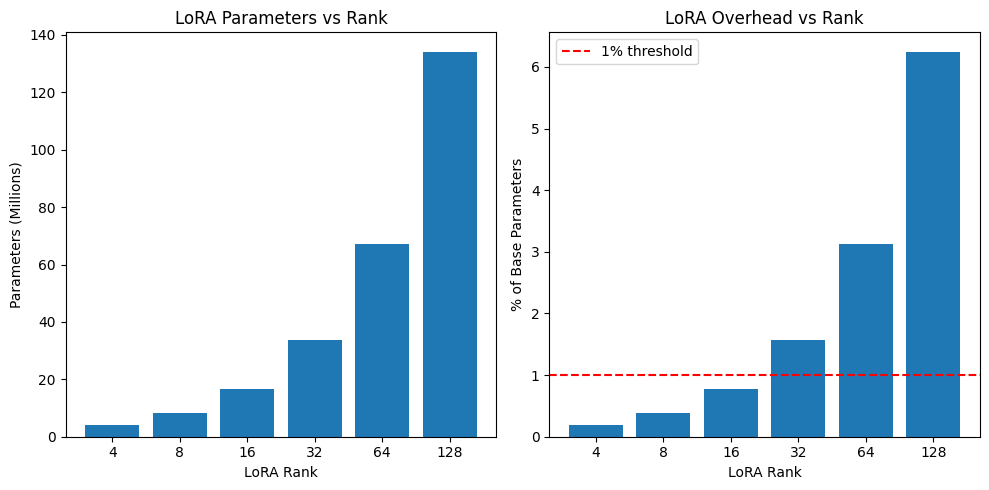


Base attention parameters: 2.15B
Rank   4:    4.2M params (0.195%)
Rank   8:    8.4M params (0.391%)
Rank  16:   16.8M params (0.781%)
Rank  32:   33.6M params (1.562%)
Rank  64:   67.1M params (3.125%)
Rank 128:  134.2M params (6.250%)


In [47]:
####test cell
# Visualize LoRA parameter counts for different configurations
import matplotlib.pyplot as plt

d_model = 4096  # Typical for 7B model
n_layers = 32
n_attention_matrices = 4  # q, k, v, o

ranks = [4, 8, 16, 32, 64, 128]

base_params_per_layer = n_attention_matrices * d_model * d_model
base_total = n_layers * base_params_per_layer

lora_params = []
for r in ranks:
    params_per_layer = n_attention_matrices * 2 * r * d_model  # A and B matrices
    total = n_layers * params_per_layer
    lora_params.append(total)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(len(ranks)), [p / 1e6 for p in lora_params])
plt.xticks(range(len(ranks)), ranks)
plt.xlabel('LoRA Rank')
plt.ylabel('Parameters (Millions)')
plt.title('LoRA Parameters vs Rank')

plt.subplot(1, 2, 2)
plt.bar(range(len(ranks)), [p / base_total * 100 for p in lora_params])
plt.xticks(range(len(ranks)), ranks)
plt.xlabel('LoRA Rank')
plt.ylabel('% of Base Parameters')
plt.title('LoRA Overhead vs Rank')
plt.axhline(y=1, color='r', linestyle='--', label='1% threshold')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nBase attention parameters: {base_total/1e9:.2f}B")
for r, p in zip(ranks, lora_params):
    print(f"Rank {r:3d}: {p/1e6:6.1f}M params ({p/base_total*100:.3f}%)")

## Summary

### What You Learned

1. **LoRA Motivation**: Parameter-efficient fine-tuning saves memory and storage
2. **LoRA Math**: W' = W + BA with low-rank matrices
3. **Implementation**: LoRALinear and LoRAWrapper classes
4. **Weight Merging**: Merge for inference, no added latency
5. **Hyperparameters**: rank, alpha, target_modules

### Key Takeaways

- LoRA trains only ~0.1-1% of parameters
- B initialized to zeros, A with Kaiming uniform
- Scaling factor α/r controls update magnitude
- Can merge weights for inference (no overhead)
- Usually applied to attention projections

### Next: Unsloth Setup

In Notebook 11, we'll set up Unsloth for efficient LoRA fine-tuning of real LLMs!